In [1]:
from baselines.Custom import ippo_ff_mpe, ippo_rnn_mpe, mappo_rnn_mpe
import importlib.resources as resources
import yaml
from omegaconf import OmegaConf
import os
os.environ["WANDB_NOTEBOOK_NAME"] = "Playground.ipynb"


import jax
import jax.numpy as jnp
import flax
import numpy as np
from matplotlib import animation
from IPython.display import HTML, display
import jaxmarl
from jaxmarl.environments.mpe.simple_spread import SimpleSpreadMPE
from jaxmarl.wrappers.baselines import MPELogWrapper
from baselines.Custom.ippo_rnn_mpe import ActorCriticRNN, ScannedRNN 



In [2]:
import jax
import jaxlib
import flax

print(jax.devices())
print("JAX version:", jax.__version__)
print("JAXlib version:", jaxlib.__version__)
print("Flax version:", flax.__version__)


[CudaDevice(id=0)]
JAX version: 0.4.38
JAXlib version: 0.4.38
Flax version: 0.10.1


In [36]:
algo_and_config_map = {
    "ippo_ff_mpe": (ippo_ff_mpe, OmegaConf.load(resources.files("baselines.Custom.config") / "ippo_ff_mpe_simple_spread.yaml")),
    "ippo_rnn_mpe": (ippo_rnn_mpe, OmegaConf.load(resources.files("baselines.Custom.config") / "ippo_rnn_mpe_simple_spread.yaml")),
    "mappo_rnn_mpe": (mappo_rnn_mpe, OmegaConf.load(resources.files("baselines.Custom.config") / "mappo_homogenous_rnn_mpe_simple_spread.yaml"))
}

In [34]:
%%time
ALGO_NAME = "ippo_rnn_mpe"
algo, config = algo_and_config_map[ALGO_NAME]

CPU times: user 2 μs, sys: 0 ns, total: 2 μs
Wall time: 5.48 μs


In [35]:
config

{'ENV_NAME': 'MPE_simple_spread_v3', 'LR': 0.0005, 'NUM_ENVS': 1, 'NUM_STEPS': 128, 'FC_DIM_SIZE': 128, 'GRU_HIDDEN_DIM': 128, 'TOTAL_TIMESTEPS': 10000.0, 'UPDATE_EPOCHS': 4, 'NUM_MINIBATCHES': 2, 'GAMMA': 0.99, 'GAE_LAMBDA': 0.95, 'CLIP_EPS': 0.3, 'SCALE_CLIP_EPS': False, 'ENT_COEF': 0.01, 'VF_COEF': 1.0, 'MAX_GRAD_NORM': 0.5, 'ACTIVATION': 'tanh', 'ANNEAL_LR': True, 'SEED': 30, 'ENTITY': 'dbraga14-princeton-university', 'PROJECT': 'scaling', 'WANDB_MODE': 'offline', 'RUN_NAME': 'ippo-rnn-simple-spread'}

In [ ]:
%%time
ALGO_NAME = "ippo_rnn_mpe"
algo, config = algo_and_config_map[ALGO_NAME]

out = algo.main(config)

2025-10-08 21:36:25.917987: W external/xla/xla/service/gpu/autotuning/gemm_fusion_autotuner.cc:1034] Compiling 316 configs for 12 fusions on a single thread.


In [5]:
def load_params_offline(path="wandb/offline-run-20251008_121315-shellov1/files/final_model_params.msgpack"):
    """Load Flax parameters from a local W&B offline run folder."""
    with open(path, "rb") as f:
        params = flax.serialization.from_bytes(None, f.read())
    return params
params = load_params_offline(
    path="wandb/offline-run-20251008_121315-shellov1/files/final_model_params.msgpack"
)

In [6]:
params['params'].keys()

dict_keys(['Dense_0', 'Dense_1', 'Dense_2', 'Dense_3', 'Dense_4', 'ScannedRNN_0'])

In [31]:
%%time
config['NUM_ENVS'] = 1
env = MPELogWrapper(jaxmarl.make(config["ENV_NAME"], max_steps=100))
rng = jax.random.PRNGKey(42)
rngs = jax.random.split(rng, config["NUM_ENVS"])
obs, env_state = jax.vmap(env.reset, in_axes=(0,))(rngs)
network = ActorCriticRNN(env.action_space(env.agents[0]).n, config)
num_actors = env.num_agents * config["NUM_ENVS"]
hstate = ScannedRNN.initialize_carry(num_actors, config["GRU_HIDDEN_DIM"])

state_seq = [env_state.env_state]

for _ in range(100):
        # batchify obs for RNN: (num_actors, obs_dim)
        obs_batch = jnp.stack([obs[a] for a in env.agents])
        obs_batch = obs_batch.transpose(1, 0, 2).reshape(-1, obs_batch.shape[-1])
        dones = jnp.zeros((num_actors,), dtype=jnp.float32)
        ac_in = (obs_batch[None, :, :], dones[None, :])  # add time dim for scan

        hstate, pi, _ = network.apply(params, hstate, ac_in)

        # sample actions
        rng, _rng = jax.random.split(rng)
        actions = pi.sample(seed=_rng)

        # unbatch actions for environment
        actions = actions.reshape(config["NUM_ENVS"], env.num_agents)
        act_dict = {a: np.array(actions[:, i]) for i, a in enumerate(env.agents)}

        rng_step = jax.random.split(_rng, config["NUM_ENVS"])
        obs, env_state, reward, done, info = jax.vmap(env.step, in_axes=(0, 0, 0))(
            rng_step, env_state, act_dict
        )
        
        state_seq.append(env_state.env_state)

/home/dbraga/.conda/envs/jaxmarl/lib/python3.10/site-packages/matplotlib/animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


CPU times: user 28.1 s, sys: 518 ms, total: 28.6 s
Wall time: 29.3 s


In [32]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from typing import Optional
import numpy as np

ALPHABET = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"

class MPEVisualizer(object):
    def __init__(
        self,
        env,
        state_seq: list,
        reward_seq=None,
    ):
        self.env = env

        self.interval = 100
        self.state_seq = state_seq
        self.reward_seq = reward_seq
        
        
        self.comm_active = not np.all(self.env.silent)
        print('Comm active? ', self.comm_active)
        
        self.init_render()

    def animate(
        self,
        save_fname: Optional[str] = None,
        view: bool = True,
    ):
        """Anim for 2D fct - x (#steps, #pop, 2) & fitness (#steps, #pop)"""
        self.ani = animation.FuncAnimation(
            self.fig,
            self.update,
            frames=len(self.state_seq),
            blit=False,
            interval=self.interval,
        )
        # Save the animation to a gif
        if save_fname is not None:
            self.ani.save(save_fname)

        if view:
            return HTML(self.ani.to_jshtml())
        return self.ani

    def init_render(self):
        from matplotlib.patches import Circle
        state = self.state_seq[0]
        
        self.fig, self.ax = plt.subplots(1, 1, figsize=(5, 5))
        
        ax_lim = 2
        self.ax.set_xlim([-ax_lim, ax_lim])
        self.ax.set_ylim([-ax_lim, ax_lim])
        
        self.entity_artists = []
        for i in range(self.env.num_entities):
            c = Circle(
                state.p_pos[0][i], self.env.rad[i], color=np.array(self.env.colour[i]) / 255
            )
            self.ax.add_patch(c)
            self.entity_artists.append(c)
            
        self.step_counter = self.ax.text(-1.95, 1.95, f"Step: {state.step}", va="top")
        
        if self.comm_active:
            self.comm_idx = np.where(self.env.silent == 0)[0]
            print('comm idx', self.comm_idx)
            self.comm_artists = []
            i = 0
            for idx in self.comm_idx:
                
                letter = ALPHABET[np.argmax(state.c[idx])]
                a = self.ax.text(-1.95, -1.95 + i*0.17, f"{self.env.agents[idx]} sends {letter}")
                
                self.comm_artists.append(a)
                i += 1
            
    def update(self, frame):
        state = self.state_seq[frame]
        for i, c in enumerate(self.entity_artists):
            c.center = state.p_pos[0][i]
            
        self.step_counter.set_text(f"Step: {state.step}")
        
        if self.comm_active:
            for i, a in enumerate(self.comm_artists):
                idx = self.comm_idx[i]
                letter = ALPHABET[np.argmax(state.c[idx])]
                a.set_text(f"{self.env.agents[idx]} sends {letter}")
        

Comm active?  False


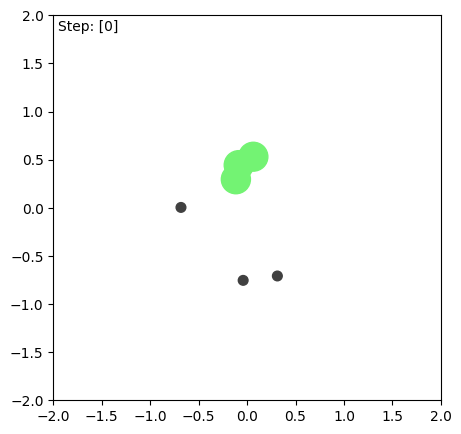

In [33]:
env_spread = jaxmarl.make("MPE_simple_spread_v3")
viz = MPEVisualizer(env_spread, state_seq)
viz.animate()